#Imports Libraries and Tool


In [ ]:
!pip install tensorflow matplotlib seaborn scikit-learn pillow


In [ ]:
pip install numpy

In [ ]:
pip install pillow

In [ ]:
pip install tensorflow

In [ ]:
pip install scikit-learn

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image, ImageEnhance
from sklearn.utils import shuffle
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize

import tensorflow as tf
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Input, Flatten, Dense, Dropout
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.optimizers import Adam


#Load Datasets


In [ ]:
# ==========================================
# 📂 Load Datasets
# ==========================================
train_dir = '/content/drive/MyDrive/MRI Images - 2/Training'
test_dir = '/content/drive/MyDrive/MRI Images - 2/Testing'

# Load and shuffle the train data
train_paths, train_labels = [], []
for label in os.listdir(train_dir):
    for image in os.listdir(os.path.join(train_dir, label)):
        train_paths.append(os.path.join(train_dir, label, image))
        train_labels.append(label)

train_paths, train_labels = shuffle(train_paths, train_labels)

# Load and shuffle the test data
test_paths, test_labels = [], []
for label in os.listdir(test_dir):
    for image in os.listdir(os.path.join(test_dir, label)):
        test_paths.append(os.path.join(test_dir, label, image))
        test_labels.append(label)

test_paths, test_labels = shuffle(test_paths, test_labels)

# 🧠 Data Augmentation & Preprocessing

In [ ]:
# 🧠 Data Augmentation & Preprocessing
# ==========================================
IMAGE_SIZE = 128

def augment_image(image):
    image = Image.fromarray(np.uint8(image))
    image = ImageEnhance.Brightness(image).enhance(random.uniform(0.8, 1.2))
    image = ImageEnhance.Contrast(image).enhance(random.uniform(0.8, 1.2))
    image = np.array(image) / 255.0
    return image

def open_images(paths):
    images = []
    for path in paths:
        image = load_img(path, target_size=(IMAGE_SIZE, IMAGE_SIZE))
        image = np.array(image)
        image = augment_image(image)
        images.append(image)
    return np.array(images)

def encode_label(labels):
    unique_labels = os.listdir(train_dir)
    encoded = [unique_labels.index(label) for label in labels]
    return np.array(encoded)

def datagen(paths, labels, batch_size=12, epochs=1):
    for _ in range(epochs):
        for i in range(0, len(paths), batch_size):
            batch_paths = paths[i:i + batch_size]
            batch_images = open_images(batch_paths)
            batch_labels = encode_label(labels[i:i + batch_size])
            yield batch_images, batch_labels


# 🧩 Build Model using MobileNetV2

In [ ]:
# ==========================================
# 🧩 Build Model using MobileNetV2
# ==========================================
base_model = MobileNetV2(input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3),
                         include_top=False,
                         weights='imagenet')

# Freeze most layers
for layer in base_model.layers[:-20]:
    layer.trainable = False

model = Sequential([
    Input(shape=(IMAGE_SIZE, IMAGE_SIZE, 3)),
    base_model,
    Flatten(),
    Dropout(0.3),
    Dense(128, activation='relu'),
    Dropout(0.2),
    Dense(len(os.listdir(train_dir)), activation='softmax')
])

model.compile(optimizer=Adam(learning_rate=0.0001),
              loss='sparse_categorical_crossentropy',
              metrics=['sparse_categorical_accuracy'])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 20480)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 20480)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     2,621,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,880,068 (18.62 MB)

 Trainable params: 3,828,164 (14.60 MB)

 Non-trainable params: 1,051,904 (4.01 MB)

# 🚀 Train the Model

In [ ]:
# 🚀 Train the Model
# ==========================================
batch_size = 20
steps = int(len(train_paths) / batch_size)
epochs = 5

history = model.fit(datagen(train_paths, train_labels, batch_size=batch_size, epochs=epochs),
                    epochs=epochs, steps_per_epoch=steps)


Epoch 1/5
291/291 ━━━━━━━━━━━━━━━━━━━━ 162s 516ms/step - loss: 0.7281 - sparse_categorical_accuracy: 0.7658
Epoch 2/5
291/291 ━━━━━━━━━━━━━━━━━━━━ 156s 535ms/step - loss: 0.1415 - sparse_categorical_accuracy: 0.9461
Epoch 3/5
291/291 ━━━━━━━━━━━━━━━━━━━━ 165s 565ms/step - loss: 0.0752 - sparse_categorical_accuracy: 0.9723
Epoch 4/5
291/291 ━━━━━━━━━━━━━━━━━━━━ 159s 548ms/step - loss: 0.0375 - sparse_categorical_accuracy: 0.9857
Epoch 5/5
291/291 ━━━━━━━━━━━━━━━━━━━━ 159s 547ms/step - loss: 0.0400 - sparse_categorical_accuracy: 0.9843


#Train and  Plots

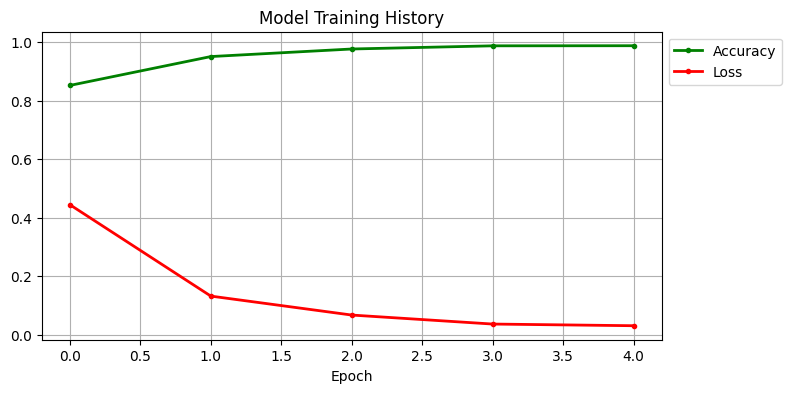

In [ ]:
plt.figure(figsize=(8,4))
plt.grid(True)
plt.plot(history.history['sparse_categorical_accuracy'], '.g-', linewidth=2)
plt.plot(history.history['loss'], '.r-', linewidth=2)
plt.title('Model Training History')
plt.xlabel('Epoch')
plt.legend(['Accuracy', 'Loss'], loc='upper left', bbox_to_anchor=(1, 1))
plt.show()

# 🧾 Evaluation matrix

41/41 ━━━━━━━━━━━━━━━━━━━━ 21s 467ms/step
Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       405
           1       0.99      0.99      0.99       300
           2       0.85      0.97      0.91       306
           3       0.99      0.86      0.92       300

    accuracy                           0.95      1311
   macro avg       0.95      0.95      0.95      1311
weighted avg       0.96      0.95      0.95      1311



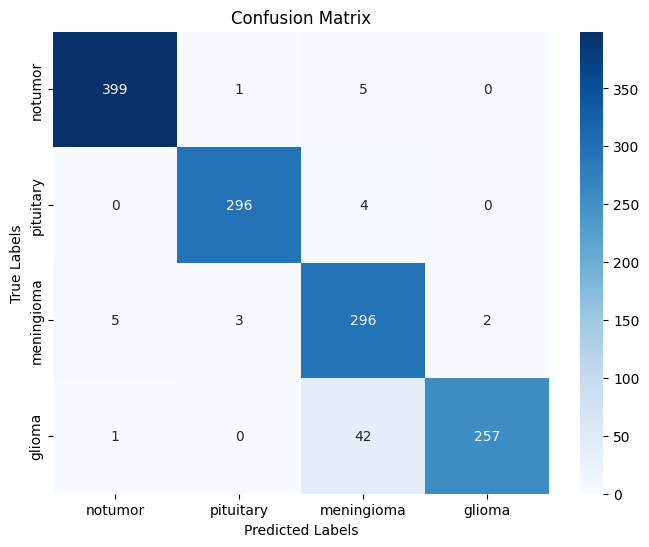

In [ ]:
# 🧾 Evaluation
# ==========================================
test_images = open_images(test_paths)
test_labels_encoded = encode_label(test_labels)
test_predictions = model.predict(test_images)

print("Classification Report:")
print(classification_report(test_labels_encoded, np.argmax(test_predictions, axis=1)))

conf_matrix = confusion_matrix(test_labels_encoded, np.argmax(test_predictions, axis=1))
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues",
            xticklabels=os.listdir(train_dir), yticklabels=os.listdir(train_dir))
plt.title("Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()

#ROC Curve Plot

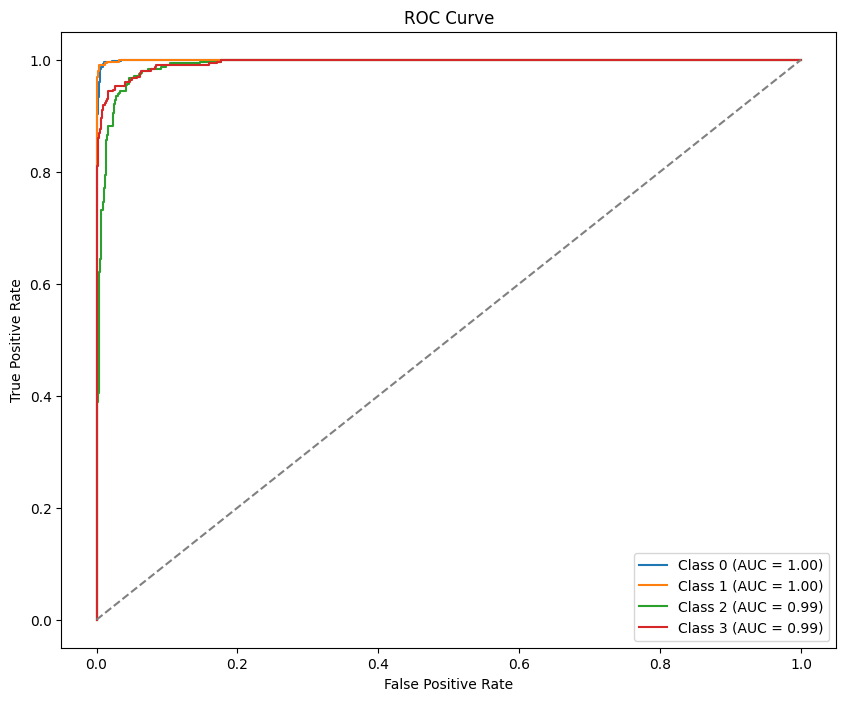

In [ ]:
# 📈 ROC Curve
# ==========================================
test_labels_bin = label_binarize(test_labels_encoded, classes=np.arange(len(os.listdir(train_dir))))
test_predictions_bin = test_predictions
fpr, tpr, roc_auc = {}, {}, {}

for i in range(len(os.listdir(train_dir))):
    fpr[i], tpr[i], _ = roc_curve(test_labels_bin[:, i], test_predictions_bin[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(10, 8))
for i in range(len(os.listdir(train_dir))):
    plt.plot(fpr[i], tpr[i], label=f'Class {i} (AUC = {roc_auc[i]:.2f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.show()


#Save & Load Model

In [ ]:
# 💾 Save and Load Model
# ==========================================
model.save('mobilenetv2_brain_tumor.h5')
model = load_model('mobilenetv2_brain_tumor.h5')

#MRI Tumor Detection System

In [ ]:
# 🧠 Prediction Function
# ==========================================
class_labels = os.listdir(train_dir)

def detect_and_display(img_path, model, image_size=128):
    try:
        img = load_img(img_path, target_size=(image_size, image_size))
        img_array = img_to_array(img) / 255.0
        img_array = np.expand_dims(img_array, axis=0)
        predictions = model.predict(img_array)
        predicted_class_index = np.argmax(predictions, axis=1)[0]
        confidence_score = np.max(predictions, axis=1)[0]
        result = (f"No Tumor" if class_labels[predicted_class_index] == 'notumor'
                  else f"Tumor: {class_labels[predicted_class_index]}")
        plt.imshow(load_img(img_path))
        plt.axis('off')
        plt.title(f"{result} (Confidence: {confidence_score * 100:.2f}%)")
        plt.show()
    except Exception as e:
        print("Error processing the image:", str(e))

# here run the model with test data

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


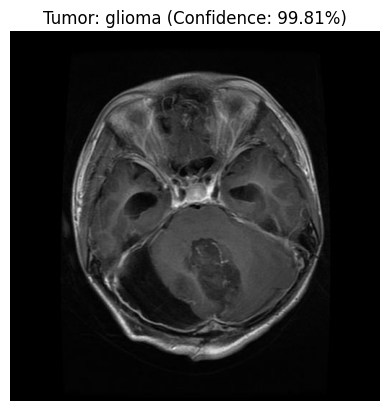

In [ ]:
# Example usage:
image_path = '/content/drive/MyDrive/MRI Images - 2/Testing/glioma/Te-glTr_0000.jpg'
detect_and_display(image_path, model)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step


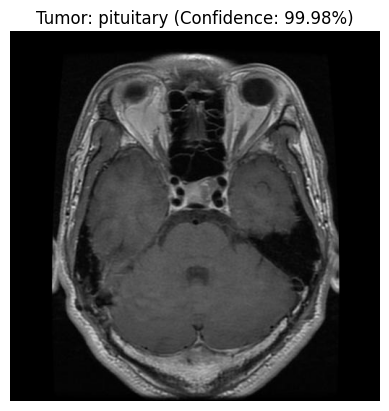

In [ ]:
# Example usage:
image_path = '/content/drive/MyDrive/MRI Images - 2/Testing/pituitary/Te-piTr_0000.jpg'
detect_and_display(image_path, model)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step


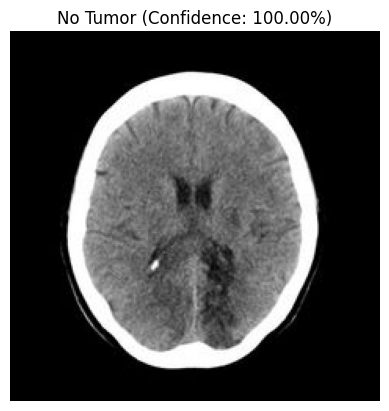

In [ ]:
# Example usage:
image_path = '/content/drive/MyDrive/MRI Images - 2/Testing/notumor/Te-no_0012.jpg'
detect_and_display(image_path, model)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step


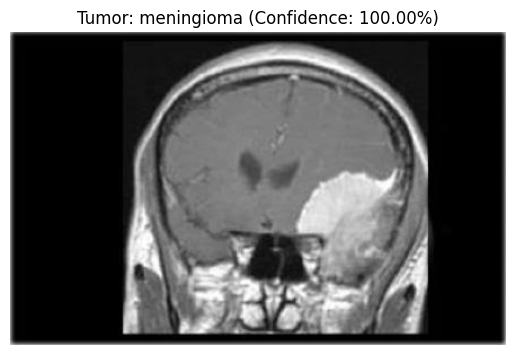

In [ ]:
# Example usage:
image_path = '/content/drive/MyDrive/MRI Images - 2/Testing/meningioma/Te-meTr_0000.jpg'
detect_and_display(image_path, model)

#predict from training set

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step


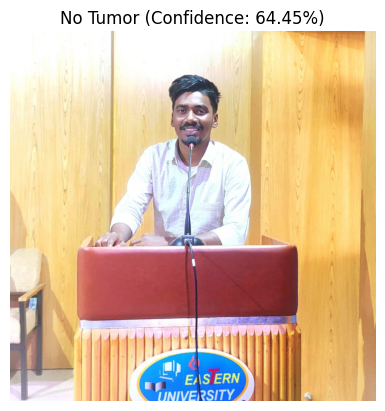

In [ ]:
# Example usage:
image_path = '/content/drive/MyDrive/MRI Images/Random/sohan.jpg'
detect_and_display(image_path, model)

#So, overall the model predict the brain_tumor correctly and confidently.